In [ ]:
# ============================================================
# ACL Tear Detection — V12 Multi-Task MRNet
# ============================================================
# V11 AUC: ACL=0.923, Men=0.794, Abn=0.770 (Composite=0.854)
# V12 adds 4 anti-overfitting techniques:
#   1. Higher dropout (0.3 -> 0.5)
#   2. Mild intensity augmentation (numpy-level, safe)
#   3. Random slice dropout (drop 15% of slices during training)
#   4. Label smoothing (0.05)
# ============================================================


# Cell 1: Mount Drive (Colab)

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Cell 2: Configuration

In [4]:
DATA_DIR = '/content/drive/MyDrive/dataset/mrnet_all'
BATCH_SIZE = 1
NUM_EPOCHS = 50
RANDOM_SEED = 42
MAX_SLICES = 40
LR = 1e-4
WEIGHT_DECAY = 0.01
PATIENCE = 10
DROPOUT = 0.4              # V11: 0.3 -> V12: 0.5


# Loss weights for each task
TASK_WEIGHT_ACL = 1.0
TASK_WEIGHT_MENISCUS = 1.0
TASK_WEIGHT_ABNORMAL = 0.5

# Model selection weights (for composite AUC)
SEL_WEIGHT_ACL = 0.5
SEL_WEIGHT_MEN = 0.3
SEL_WEIGHT_ABN = 0.2

# Cell 3: Imports

In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
  GPU: Tesla T4


# Cell 4: Load Metadata + Split

In [5]:
data_path = Path(DATA_DIR)
metadata = pd.read_csv(data_path / 'metadata.csv')

print(f"Total patients: {len(metadata)}")
print(f"\nLabel distribution:")
print(f"  ACL tear:      {metadata.label_acl.sum():4d} / {len(metadata)} ({100*metadata.label_acl.mean():.1f}%)")
print(f"  Meniscus tear: {metadata.label_meniscus.sum():4d} / {len(metadata)} ({100*metadata.label_meniscus.mean():.1f}%)")
print(f"  Abnormal:      {metadata.label_abnormal.sum():4d} / {len(metadata)} ({100*metadata.label_abnormal.mean():.1f}%)")
print(f"  Normal (all 0): {((metadata.label_abnormal==0)).sum():4d} / {len(metadata)}")

# Stratified split on ACL label (primary task)
train_df, val_df = train_test_split(
    metadata, test_size=0.15, random_state=RANDOM_SEED,
    stratify=metadata['label_acl']
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"\nTrain: {len(train_df)} patients")
print(f"  ACL: {train_df.label_acl.sum()} tear / {(train_df.label_acl==0).sum()} normal")
print(f"  Meniscus: {train_df.label_meniscus.sum()} tear / {(train_df.label_meniscus==0).sum()} normal")
print(f"  Abnormal: {train_df.label_abnormal.sum()} yes / {(train_df.label_abnormal==0).sum()} no")
print(f"\nVal: {len(val_df)} patients")
print(f"  ACL: {val_df.label_acl.sum()} tear / {(val_df.label_acl==0).sum()} normal")

Total patients: 1250

Label distribution:
  ACL tear:       262 / 1250 (21.0%)
  Meniscus tear:  449 / 1250 (35.9%)
  Abnormal:      1008 / 1250 (80.6%)
  Normal (all 0):  242 / 1250

Train: 1062 patients
  ACL: 223 tear / 839 normal
  Meniscus: 376 tear / 686 normal
  Abnormal: 853 yes / 209 no

Val: 188 patients
  ACL: 39 tear / 149 normal


# Cell 5: Dataset — Mild Augmentation + Slice Dropout

In [6]:
class MultiTaskDataset(Dataset):
    """Loads sagittal view with mild augmentation, slice dropout, and 3 labels."""
    def __init__(self, df, data_dir, max_slices=MAX_SLICES, augment=False):
        self.df = df.reset_index(drop=True)
        self.data_dir = Path(data_dir)
        self.max_slices = max_slices
        self.augment = augment
        self.valid_indices = []

        for idx in range(len(self.df)):
            fpath = self.data_dir / self.df.iloc[idx]['filename']
            if fpath.exists():
                self.valid_indices.append(idx)

        print(f"  {len(self.valid_indices)} valid patients (of {len(self.df)})")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patient_idx = self.valid_indices[idx]
        row = self.df.iloc[patient_idx]

        data = np.load(self.data_dir / row['filename'])
        volume = data['sagittal']  # (S, 256, 256), uint8
        slices = volume.astype(np.float32) / 255.0
        actual_slices = slices.shape[0]

        # Center crop if too many slices
        if actual_slices > self.max_slices:
            offset = (actual_slices - self.max_slices) // 2
            slices = slices[offset:offset + self.max_slices]

        if self.augment:
            if np.random.random() > 0.5:
                slices = slices[:, :, ::-1].copy()


        # Stack to 3 channels
        slices_3ch = np.stack((slices,)*3, axis=1)  # (S, 3, 256, 256)
        tensor = torch.FloatTensor(slices_3ch)

        # Multi-task labels
        labels = torch.LongTensor([
            int(row['label_acl']),
            int(row['label_meniscus']),
            int(row['label_abnormal'])
        ])

        return tensor, labels

    def get_label_counts(self):
        """Get per-task label counts for class weight computation."""
        acl = [int(self.df.iloc[i]['label_acl']) for i in self.valid_indices]
        men = [int(self.df.iloc[i]['label_meniscus']) for i in self.valid_indices]
        abn = [int(self.df.iloc[i]['label_abnormal']) for i in self.valid_indices]
        return {'acl': acl, 'meniscus': men, 'abnormal': abn}

# Create datasets
print("Creating datasets...")
print("Train:")
train_dataset = MultiTaskDataset(train_df, DATA_DIR, augment=True)
print("Val:")
val_dataset = MultiTaskDataset(val_df, DATA_DIR, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

Creating datasets...
Train:
  1062 valid patients (of 1062)
Val:
  188 valid patients (of 188)


# Cell 6: Compute Class Weights

In [7]:
label_counts = train_dataset.get_label_counts()

def compute_weight(labels):
    n = len(labels)
    n_pos = sum(labels)
    n_neg = n - n_pos
    w_neg = n / (2 * n_neg) if n_neg > 0 else 1.0
    w_pos = n / (2 * n_pos) if n_pos > 0 else 1.0
    return torch.FloatTensor([w_neg, w_pos]).to(device)

weight_acl = compute_weight(label_counts['acl'])
weight_meniscus = compute_weight(label_counts['meniscus'])
weight_abnormal = compute_weight(label_counts['abnormal'])

print(f"Class weights:")
print(f"  ACL:      Normal={weight_acl[0]:.3f}, Tear={weight_acl[1]:.3f}")
print(f"  Meniscus: Normal={weight_meniscus[0]:.3f}, Tear={weight_meniscus[1]:.3f}")
print(f"  Abnormal: Normal={weight_abnormal[0]:.3f}, Abnormal={weight_abnormal[1]:.3f}")

Class weights:
  ACL:      Normal=0.633, Tear=2.381
  Meniscus: Normal=0.774, Tear=1.412
  Abnormal: Normal=2.541, Abnormal=0.623


# Cell 7: Model — V11 Architecture + Higher Dropout

In [8]:
"""MRNetV13 — V11 architecture + Task-Specific Attention MIL.
Based on V11 (composite=0.854), NOT V12's broken regularization.
Key: attention + max-pool residual so training starts stable.
"""
import torch
import torch.nn as nn
import torchvision.models as models


class MRNetV13(nn.Module):
    """Multi-task MRNet with task-specific attention.
    volume_feat = alpha * attention_feat + (1-alpha) * maxpool_feat
    alpha starts at sigmoid(-2)=0.12 (mostly max-pool) and learns to shift.
    """
    def __init__(self, dropout=0.3):
        super().__init__()
        backbone = models.efficientnet_b0(weights='IMAGENET1K_V1')
        self.features = backbone.features
        self.pool = backbone.avgpool
        self.drop = nn.Dropout(p=dropout)

        # Simple attention per task (Ilse et al., 2018)
        self.attn_acl = self._make_attention(1280, 128)
        self.attn_meniscus = self._make_attention(1280, 128)
        self.attn_abnormal = self._make_attention(1280, 128)

        # Learnable mixing: sigmoid(-2)=0.12 → starts as mostly max-pool
        self.alpha_acl = nn.Parameter(torch.tensor(0.0))
        self.alpha_men = nn.Parameter(torch.tensor(0.0))
        self.alpha_abn = nn.Parameter(torch.tensor(0.0))

        # Task heads (same as V11)
        self.head_acl = nn.Linear(1280, 2)
        self.head_meniscus = nn.Linear(1280, 2)
        self.head_abnormal = nn.Linear(1280, 2)

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"  Backbone: EfficientNet-B0 (all trainable)")
        print(f"  Pooling: Attention + MaxPool residual (per task)")
        print(f"  Alpha init: sigmoid(-2) = {torch.sigmoid(torch.tensor(-2.0)):.2f} (mostly max-pool)")
        print(f"  Heads: ACL, Meniscus, Abnormal (1280->2 each)")
        print(f"  Dropout: {dropout}")
        print(f"  Params: {trainable:,} trainable / {total:,} total")

    def _make_attention(self, in_dim, hidden_dim):
        """Simple attention — Linear -> Tanh -> Linear -> softmax."""
        return nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def _attend(self, attn_module, pooled, alpha):
        """Attention-weighted pooling with max-pool residual."""
        scores = attn_module(pooled)
        weights = torch.softmax(scores, dim=0)
        attn_feat = (weights * pooled).sum(dim=0, keepdim=True)

        max_feat = torch.max(pooled, 0, keepdim=True)[0]

        mix = torch.sigmoid(alpha)
        feat = mix * attn_feat + (1 - mix) * max_feat

        return feat, weights

    def forward(self, x):
        x = x.squeeze(0)
        features = self.features(x)
        pooled = self.pool(features).flatten(1)

        feat_acl, _ = self._attend(self.attn_acl, pooled, self.alpha_acl)
        feat_men, _ = self._attend(self.attn_meniscus, pooled, self.alpha_men)
        feat_abn, _ = self._attend(self.attn_abnormal, pooled, self.alpha_abn)

        out_acl = self.head_acl(self.drop(feat_acl))
        out_men = self.head_meniscus(self.drop(feat_men))
        out_abn = self.head_abnormal(self.drop(feat_abn))

        return out_acl, out_men, out_abn

    def get_attention_weights(self, x):
        """Returns per-task attention weights + mixing alphas for visualization."""
        self.eval()
        with torch.no_grad():
            x = x.squeeze(0)
            features = self.features(x)
            pooled = self.pool(features).flatten(1)

            _, w_acl = self._attend(self.attn_acl, pooled, self.alpha_acl)
            _, w_men = self._attend(self.attn_meniscus, pooled, self.alpha_men)
            _, w_abn = self._attend(self.attn_abnormal, pooled, self.alpha_abn)

        return {
            'acl': w_acl.squeeze(-1).cpu().numpy(),
            'meniscus': w_men.squeeze(-1).cpu().numpy(),
            'abnormal': w_abn.squeeze(-1).cpu().numpy(),
            'mix_acl': torch.sigmoid(self.alpha_acl).item(),
            'mix_men': torch.sigmoid(self.alpha_men).item(),
            'mix_abn': torch.sigmoid(self.alpha_abn).item(),
        }


In [10]:
model = MRNetV13(dropout=DROPOUT).to(device)

  Backbone: EfficientNet-B0 (all trainable)
  Pooling: Attention + MaxPool residual (per task)
  Alpha init: sigmoid(-2) = 0.12 (mostly max-pool)
  Heads: ACL, Meniscus, Abnormal (1280->2 each)
  Dropout: 0.4
  Params: 4,507,528 trainable / 4,507,528 total


# Cell 8: Loss + Optimizer + Scheduler

In [11]:
criterion_acl = nn.CrossEntropyLoss(weight=weight_acl)
criterion_meniscus = nn.CrossEntropyLoss(weight=weight_meniscus)
criterion_abnormal = nn.CrossEntropyLoss(weight=weight_abnormal)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=5, min_lr=1e-7
)

print(f"Optimizer: Adam (lr={LR}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler: ReduceLROnPlateau (patience=5, factor=0.3, on composite AUC)")
print(f"Task weights: ACL={TASK_WEIGHT_ACL}, Men={TASK_WEIGHT_MENISCUS}, Abn={TASK_WEIGHT_ABNORMAL}")
print(f"Selection weights: ACL={SEL_WEIGHT_ACL}, Men={SEL_WEIGHT_MEN}, Abn={SEL_WEIGHT_ABN}")

Optimizer: Adam (lr=0.0001, weight_decay=0.01)
Scheduler: ReduceLROnPlateau (patience=5, factor=0.3, on composite AUC)
Task weights: ACL=1.0, Men=1.0, Abn=0.5
Selection weights: ACL=0.5, Men=0.3, Abn=0.2


# Cell 9: Train + Validate Functions

In [12]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    all_labels = {'acl': [], 'meniscus': [], 'abnormal': []}
    all_probs = {'acl': [], 'meniscus': [], 'abnormal': []}

    for volumes, labels in tqdm(loader, desc='Training', leave=False):
        volumes = volumes.to(device)
        lab_acl = labels[:, 0].to(device)
        lab_men = labels[:, 1].to(device)
        lab_abn = labels[:, 2].to(device)

        optimizer.zero_grad()
        out_acl, out_men, out_abn = model(volumes.float())

        loss_acl = criterion_acl(out_acl, lab_acl)
        loss_men = criterion_meniscus(out_men, lab_men)
        loss_abn = criterion_abnormal(out_abn, lab_abn)

        loss = (TASK_WEIGHT_ACL * loss_acl +
                TASK_WEIGHT_MENISCUS * loss_men +
                TASK_WEIGHT_ABNORMAL * loss_abn)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Collect predictions
        probs_acl = torch.softmax(out_acl, dim=1)[:, 1].detach().cpu().numpy()
        probs_men = torch.softmax(out_men, dim=1)[:, 1].detach().cpu().numpy()
        probs_abn = torch.softmax(out_abn, dim=1)[:, 1].detach().cpu().numpy()

        all_labels['acl'].extend(lab_acl.cpu().numpy())
        all_labels['meniscus'].extend(lab_men.cpu().numpy())
        all_labels['abnormal'].extend(lab_abn.cpu().numpy())
        all_probs['acl'].extend(probs_acl)
        all_probs['meniscus'].extend(probs_men)
        all_probs['abnormal'].extend(probs_abn)

    avg_loss = total_loss / len(loader)
    aucs = {}
    for task in ['acl', 'meniscus', 'abnormal']:
        try:
            aucs[task] = roc_auc_score(all_labels[task], all_probs[task])
        except ValueError:
            aucs[task] = 0.5

    return avg_loss, aucs


def validate(model, loader, device):
    model.eval()
    total_loss = 0
    all_labels = {'acl': [], 'meniscus': [], 'abnormal': []}
    all_probs = {'acl': [], 'meniscus': [], 'abnormal': []}

    with torch.no_grad():
        for volumes, labels in tqdm(loader, desc='Validating', leave=False):
            volumes = volumes.to(device)
            lab_acl = labels[:, 0].to(device)
            lab_men = labels[:, 1].to(device)
            lab_abn = labels[:, 2].to(device)

            out_acl, out_men, out_abn = model(volumes.float())

            loss_acl = criterion_acl(out_acl, lab_acl)
            loss_men = criterion_meniscus(out_men, lab_men)
            loss_abn = criterion_abnormal(out_abn, lab_abn)

            loss = (TASK_WEIGHT_ACL * loss_acl +
                    TASK_WEIGHT_MENISCUS * loss_men +
                    TASK_WEIGHT_ABNORMAL * loss_abn)
            total_loss += loss.item()

            probs_acl = torch.softmax(out_acl, dim=1)[:, 1].cpu().numpy()
            probs_men = torch.softmax(out_men, dim=1)[:, 1].cpu().numpy()
            probs_abn = torch.softmax(out_abn, dim=1)[:, 1].cpu().numpy()

            all_labels['acl'].extend(lab_acl.cpu().numpy())
            all_labels['meniscus'].extend(lab_men.cpu().numpy())
            all_labels['abnormal'].extend(lab_abn.cpu().numpy())
            all_probs['acl'].extend(probs_acl)
            all_probs['meniscus'].extend(probs_men)
            all_probs['abnormal'].extend(probs_abn)

    avg_loss = total_loss / len(loader)
    aucs = {}
    for task in ['acl', 'meniscus', 'abnormal']:
        try:
            aucs[task] = roc_auc_score(all_labels[task], all_probs[task])
        except ValueError:
            aucs[task] = 0.5

    return avg_loss, aucs, all_labels, all_probs

# Cell 10: Training Loop

In [13]:
history = {'train_loss': [], 'val_loss': [],
           'train_auc_acl': [], 'val_auc_acl': [],
           'train_auc_men': [], 'val_auc_men': [],
           'train_auc_abn': [], 'val_auc_abn': [],
           'lr': []}

best_composite_auc = 0.0
no_improve = 0
SAVE_PATH = '/content/drive/MyDrive/dataset/best_acl_model_v12.pth'

print(f"Training for up to {NUM_EPOCHS} epochs (patience={PATIENCE})...")
print(f"V12: dropout={DROPOUT}\n")

for epoch in range(NUM_EPOCHS):
    current_lr = optimizer.param_groups[0]['lr']

    train_loss, train_aucs = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_aucs, val_labels, val_probs = validate(model, val_loader, device)

    # Log history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc_acl'].append(train_aucs['acl'])
    history['val_auc_acl'].append(val_aucs['acl'])
    history['train_auc_men'].append(train_aucs['meniscus'])
    history['val_auc_men'].append(val_aucs['meniscus'])
    history['train_auc_abn'].append(train_aucs['abnormal'])
    history['val_auc_abn'].append(val_aucs['abnormal'])
    history['lr'].append(current_lr)

    # Composite AUC for model selection
    composite_val = (SEL_WEIGHT_ACL * val_aucs['acl'] +
                     SEL_WEIGHT_MEN * val_aucs['meniscus'] +
                     SEL_WEIGHT_ABN * val_aucs['abnormal'])
    composite_train = (SEL_WEIGHT_ACL * train_aucs['acl'] +
                       SEL_WEIGHT_MEN * train_aucs['meniscus'] +
                       SEL_WEIGHT_ABN * train_aucs['abnormal'])

    # Step scheduler on composite val AUC
    scheduler.step(composite_val)

    gap = 100 * (composite_train - composite_val)
    overfit_flag = " OVERFIT" if gap > 10 else ""

    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  (lr={current_lr:.1e})")
    print(f"  Train: loss={train_loss:.4f}  ACL={train_aucs['acl']:.4f}  Men={train_aucs['meniscus']:.4f}  Abn={train_aucs['abnormal']:.4f}")
    print(f"  Val:   loss={val_loss:.4f}  ACL={val_aucs['acl']:.4f}  Men={val_aucs['meniscus']:.4f}  Abn={val_aucs['abnormal']:.4f}  (gap={gap:.1f}%){overfit_flag}")
    print(f"  Composite AUC: train={composite_train:.4f}  val={composite_val:.4f}")

    # Model selection on composite AUC
    if composite_val > best_composite_auc:
        best_composite_auc = composite_val
        no_improve = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> Saved best (Composite={best_composite_auc:.4f}, ACL={val_aucs['acl']:.4f}, Men={val_aucs['meniscus']:.4f}, Abn={val_aucs['abnormal']:.4f})")
    else:
        no_improve += 1
        print(f"  -> No improvement ({no_improve}/{PATIENCE})")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nBest composite val AUC: {best_composite_auc:.4f}")

Training for up to 50 epochs (patience=10)...
V12: dropout=0.4



Training:   0%|          | 0/1062 [00:00<?, ?it/s]

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 1/50  (lr=1.0e-04)
  Train: loss=1.4040  ACL=0.5710  Men=0.5879  Abn=0.6318
  Val:   loss=1.2831  ACL=0.7145  Men=0.7520  Abn=0.7715  (gap=-14.9%)
  Composite AUC: train=0.5882  val=0.7371
  -> Saved best (Composite=0.7371, ACL=0.7145, Men=0.7520, Abn=0.7715)


Training:   0%|          | 0/1062 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 13/50  (lr=3.0e-05)
  Train: loss=0.3967  ACL=0.9953  Men=0.9634  Abn=0.9649
  Val:   loss=2.8269  ACL=0.8983  Men=0.6388  Abn=0.7232  (gap=19.4%) OVERFIT
  Composite AUC: train=0.9796  val=0.7854
  -> No improvement (9/10)


Training:   0%|          | 0/1062 [00:00<?, ?it/s]

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

Epoch 14/50  (lr=3.0e-05)
  Train: loss=0.3303  ACL=0.9985  Men=0.9775  Abn=0.9641
  Val:   loss=2.1993  ACL=0.9269  Men=0.6739  Abn=0.7177  (gap=17.6%) OVERFIT
  Composite AUC: train=0.9853  val=0.8091
  -> No improvement (10/10)

Early stopping at epoch 14

Best composite val AUC: 0.8246


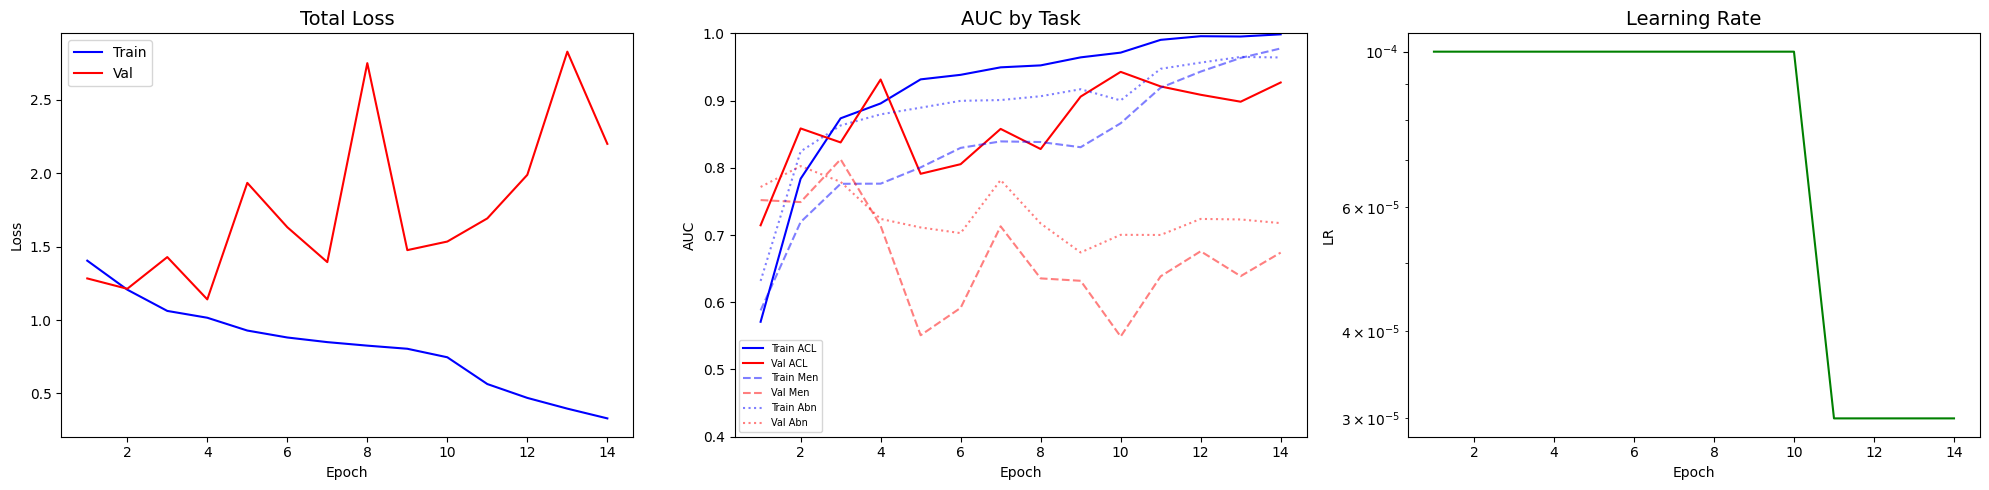

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Val')
axes[0].set_title('Total Loss', fontsize=14)
axes[0].legend()
axes[0].set_ylabel('Loss')

# AUCs
axes[1].plot(epochs_range, history['train_auc_acl'], 'b-', label='Train ACL')
axes[1].plot(epochs_range, history['val_auc_acl'], 'r-', label='Val ACL')
axes[1].plot(epochs_range, history['train_auc_men'], 'b--', alpha=0.5, label='Train Men')
axes[1].plot(epochs_range, history['val_auc_men'], 'r--', alpha=0.5, label='Val Men')
axes[1].plot(epochs_range, history['train_auc_abn'], 'b:', alpha=0.5, label='Train Abn')
axes[1].plot(epochs_range, history['val_auc_abn'], 'r:', alpha=0.5, label='Val Abn')
axes[1].set_title('AUC by Task', fontsize=14)
axes[1].legend(fontsize=7)
axes[1].set_ylabel('AUC')
axes[1].set_ylim(0.4, 1.0)

# LR
axes[2].plot(epochs_range, history['lr'], 'g-')
axes[2].set_title('Learning Rate', fontsize=14)
axes[2].set_yscale('log')
axes[2].set_ylabel('LR')

for ax in axes:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/training_history_v12.png', dpi=150)
plt.show()

# Cell 12: Final Evaluation (All Tasks)

In [15]:
model.load_state_dict(torch.load(SAVE_PATH, map_location=device, weights_only=True))
model.eval()

val_loss, val_aucs, val_labels, val_probs = validate(model, val_loader, device)

# Find optimal thresholds for each task
for task, title in [('acl', 'ACL'), ('meniscus', 'Meniscus'), ('abnormal', 'Abnormal')]:
    fpr, tpr, thresholds = roc_curve(val_labels[task], val_probs[task])
    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)
    best_thr = thresholds[best_idx]
    print(f"{title}: Optimal threshold={best_thr:.4f} (J={youden_j[best_idx]:.4f}, Sens={tpr[best_idx]:.3f}, Spec={1-fpr[best_idx]:.3f})")

label_names = ['Normal', 'Tear']

print('\n' + '=' * 60)
print('RESULTS — V12 (Multi-Task MRNet)')
print('=' * 60)
print(f'ACL AUC:      {val_aucs["acl"]:.4f}')
print(f'Meniscus AUC: {val_aucs["meniscus"]:.4f}')
print(f'Abnormal AUC: {val_aucs["abnormal"]:.4f}')
composite = SEL_WEIGHT_ACL*val_aucs["acl"] + SEL_WEIGHT_MEN*val_aucs["meniscus"] + SEL_WEIGHT_ABN*val_aucs["abnormal"]
print(f'Composite:    {composite:.4f}')

for task, title in [('acl', 'ACL'), ('meniscus', 'Meniscus'), ('abnormal', 'Abnormal')]:
    print(f'\n--- {title}: Default threshold (0.5) ---')
    preds = [1 if p >= 0.5 else 0 for p in val_probs[task]]
    print(classification_report(val_labels[task], preds, target_names=label_names, digits=3))

Validating:   0%|          | 0/188 [00:00<?, ?it/s]

ACL: Optimal threshold=0.4289 (J=0.8078, Sens=0.949, Spec=0.859)
Meniscus: Optimal threshold=0.4133 (J=0.4069, Sens=0.781, Spec=0.626)
Abnormal: Optimal threshold=0.8662 (J=0.3789, Sens=0.652, Spec=0.727)

RESULTS — V12 (Multi-Task MRNet)
ACL AUC:      0.9313
Meniscus AUC: 0.7138
Abnormal AUC: 0.7239
Composite:    0.8246

--- ACL: Default threshold (0.5) ---
              precision    recall  f1-score   support

      Normal      0.957     0.893     0.924       149
        Tear      0.673     0.846     0.750        39

    accuracy                          0.883       188
   macro avg      0.815     0.869     0.837       188
weighted avg      0.898     0.883     0.888       188


--- Meniscus: Default threshold (0.5) ---
              precision    recall  f1-score   support

      Normal      0.713     0.713     0.713       115
        Tear      0.548     0.548     0.548        73

    accuracy                          0.649       188
   macro avg      0.630     0.630     0.630       1

# Cell 13: Confusion Matrices (All Tasks)

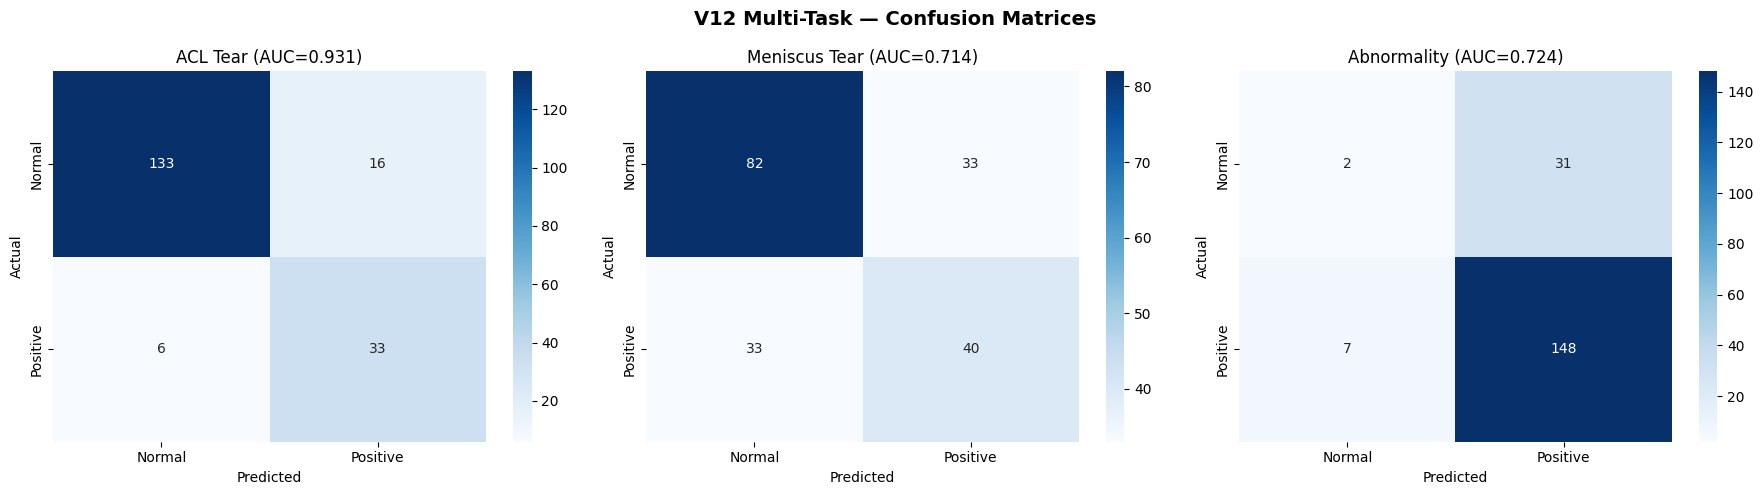

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, task, title in zip(axes,
    ['acl', 'meniscus', 'abnormal'],
    ['ACL Tear', 'Meniscus Tear', 'Abnormality']):
    preds = [1 if p >= 0.5 else 0 for p in val_probs[task]]
    cm = confusion_matrix(val_labels[task], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Positive'], yticklabels=['Normal', 'Positive'], ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{title} (AUC={val_aucs[task]:.3f})')

plt.suptitle('V12 Multi-Task — Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/dataset/confusion_matrix_v12.png', dpi=150)
plt.show()